# 04 — Model Baselines & Experimentation

**Project:** `ecommerce-delivery-delay-prediction`  
**Phase:** 4 — Model Development & Experimentation

## Goals

Train and compare a sequence of increasingly expressive binary classifiers while preserving the chronological validation strategy from Phase 3.

Model-selection rule:

**Select the best model on validation PR-AUC.**

The test set remains untouched until the winning model has been selected.

Models:

- DummyClassifier;
- Logistic Regression;
- Decision Tree;
- Random Forest;
- HistGradientBoostingClassifier.

Metrics:

- PR-AUC / Average Precision — primary;
- ROC-AUC;
- Recall;
- Precision;
- F1;
- Accuracy — reference only.

Because the positive class is rare, accuracy is not used for model selection.

## 1. Imports

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Project paths

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Không tìm thấy project root chứa data/processed."
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"

for directory in [
    MODELS_DIR,
    FIGURES_DIR,
    METRICS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /home/namdp/Documents/Projects/ecommerce-delivery-delay-prediction


## 3. Import reusable modeling code

In [3]:
from src.features.build_features import (
    MODEL_FEATURE_COLUMNS,
    TARGET_COLUMN,
)
from src.features.preprocessing import (
    select_model_matrix,
)
from src.models.evaluate import (
    classification_metrics,
    confusion_matrix_frame,
    find_best_f1_threshold,
    predict_positive_probability,
    threshold_table,
)
from src.models.model_registry import (
    get_model_registry,
)

## 4. Load chronological splits

In [4]:
train_df = pd.read_parquet(
    PROCESSED_DIR / "train.parquet"
)
validation_df = pd.read_parquet(
    PROCESSED_DIR / "validation.parquet"
)
test_df = pd.read_parquet(
    PROCESSED_DIR / "test.parquet"
)

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_df),
            "start": train_df["prediction_timestamp"].min(),
            "end": train_df["prediction_timestamp"].max(),
            "late_rate": train_df[TARGET_COLUMN].mean(),
        },
        {
            "split": "validation",
            "rows": len(validation_df),
            "start": validation_df["prediction_timestamp"].min(),
            "end": validation_df["prediction_timestamp"].max(),
            "late_rate": validation_df[TARGET_COLUMN].mean(),
        },
        {
            "split": "test",
            "rows": len(test_df),
            "start": test_df["prediction_timestamp"].min(),
            "end": test_df["prediction_timestamp"].max(),
            "late_rate": test_df[TARGET_COLUMN].mean(),
        },
    ]
)

display(split_summary)

assert len(train_df) == 67_515
assert len(validation_df) == 14_467
assert len(test_df) == 14_468

,split,rows,start,end,late_rate
0,train,67515,2016-09-15 12:16:38,2018-04-16 08:51:19,0.0902
1,validation,14467,2018-04-16 08:51:20,2018-06-21 11:59:03,0.0538
2,test,14468,2018-06-21 12:21:56,2018-08-29 15:10:26,0.0658


### Observation

The positive-class rate is not stationary across time.

Therefore train/validation differences should not automatically be interpreted as overfitting; temporal distribution shift must also be considered.

## 5. Build X / y

In [5]:
X_train = select_model_matrix(train_df)
y_train = train_df[TARGET_COLUMN].copy()

X_validation = select_model_matrix(validation_df)
y_validation = validation_df[TARGET_COLUMN].copy()

X_test = select_model_matrix(test_df)
y_test = test_df[TARGET_COLUMN].copy()

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

assert X_train.shape[1] == len(MODEL_FEATURE_COLUMNS)

X_train: (67515, 41)
X_validation: (14467, 41)
X_test: (14468, 41)


## 6. Model registry

In [6]:
registry = get_model_registry()

registry_summary = pd.DataFrame(
    [
        {
            "model": name,
            "family": spec.family,
            "description": spec.description,
        }
        for name, spec in registry.items()
    ]
)

display(registry_summary)

,model,family,description
0,dummy_prior,baseline,DummyClassifier using the training class prior.
1,logistic_regression,linear,Class-balanced logistic regression baseline.
2,decision_tree,tree,Regularized class-balanced decision tree.
3,random_forest,ensemble,Random forest with balanced subsampling.
4,hist_gradient_boosting,boosting,Histogram gradient boosting with dense one-hot...


## 7. Train all candidate models

Every model is trained only on the chronological training split.

All preprocessing is contained inside each sklearn Pipeline, so imputers, scalers and encoders are fitted on training data only.

In [7]:
import time

fitted_models = {}
validation_probabilities = {}
validation_rows = []

for name, spec in registry.items():
    print(f"Training {name} ...")

    pipeline = spec.pipeline_factory()

    started = time.perf_counter()

    pipeline.fit(
        X_train,
        y_train,
    )

    fit_seconds = (
        time.perf_counter()
        - started
    )

    probability = predict_positive_probability(
        pipeline,
        X_validation,
    )

    metrics = classification_metrics(
        y_validation,
        probability,
        threshold=0.50,
    )

    validation_rows.append(
        {
            "model": name,
            "family": spec.family,
            "fit_seconds": fit_seconds,
            **metrics,
        }
    )

    fitted_models[name] = pipeline
    validation_probabilities[name] = probability

validation_metrics = (
    pd.DataFrame(validation_rows)
    .sort_values(
        "pr_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(validation_metrics)

Training dummy_prior ...
Training logistic_regression ...
Training decision_tree ...
Training random_forest ...
Training hist_gradient_boosting ...


,model,family,fit_seconds,pr_auc,roc_auc,precision,recall,f1,accuracy,positive_rate,threshold
0,random_forest,ensemble,10.5952,0.1619,0.7515,0.2500,0.0244,0.0445,0.9436,0.0053,0.5000
1,logistic_regression,linear,4.2379,0.1531,0.7679,0.1049,0.7545,0.1842,0.6405,0.3869,0.5000
2,hist_gradient_boosting,boosting,8.5965,0.1356,0.7241,0.1467,0.2725,0.1907,0.8756,0.0999,0.5000
3,decision_tree,tree,1.2677,0.0956,0.6418,0.1064,0.3162,0.1592,0.8203,0.1599,0.5000
4,dummy_prior,baseline,0.3570,0.0538,0.5000,0.0000,0.0000,0.0000,0.9462,0.0000,0.5000


## 8. Validation model ranking

Primary model-selection metric:

**PR-AUC**

PR-AUC is appropriate because late deliveries are the minority class and it directly evaluates the precision–recall trade-off across thresholds.

In [8]:
ranking_columns = [
    "model",
    "family",
    "pr_auc",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "positive_rate",
    "fit_seconds",
]

display(
    validation_metrics[ranking_columns]
)

,model,family,pr_auc,roc_auc,precision,recall,f1,accuracy,positive_rate,fit_seconds
0,random_forest,ensemble,0.1619,0.7515,0.2500,0.0244,0.0445,0.9436,0.0053,10.5952
1,logistic_regression,linear,0.1531,0.7679,0.1049,0.7545,0.1842,0.6405,0.3869,4.2379
2,hist_gradient_boosting,boosting,0.1356,0.7241,0.1467,0.2725,0.1907,0.8756,0.0999,8.5965
3,decision_tree,tree,0.0956,0.6418,0.1064,0.3162,0.1592,0.8203,0.1599,1.2677
4,dummy_prior,baseline,0.0538,0.5000,0.0000,0.0000,0.0000,0.9462,0.0000,0.3570


## 9. Validation Precision–Recall curves

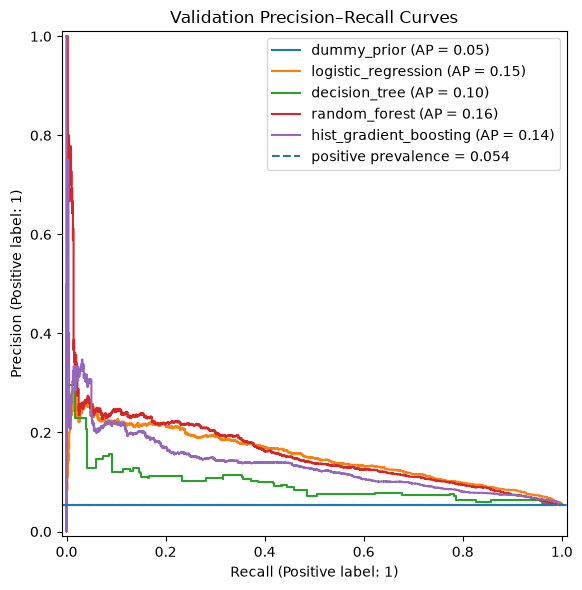

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, probability in validation_probabilities.items():
    PrecisionRecallDisplay.from_predictions(
        y_validation,
        probability,
        name=name,
        ax=ax,
    )

baseline = y_validation.mean()
ax.axhline(
    baseline,
    linestyle="--",
    label=f"positive prevalence = {baseline:.3f}",
)

ax.set_title(
    "Validation Precision–Recall Curves"
)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "12_validation_pr_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 10. Validation ROC curves

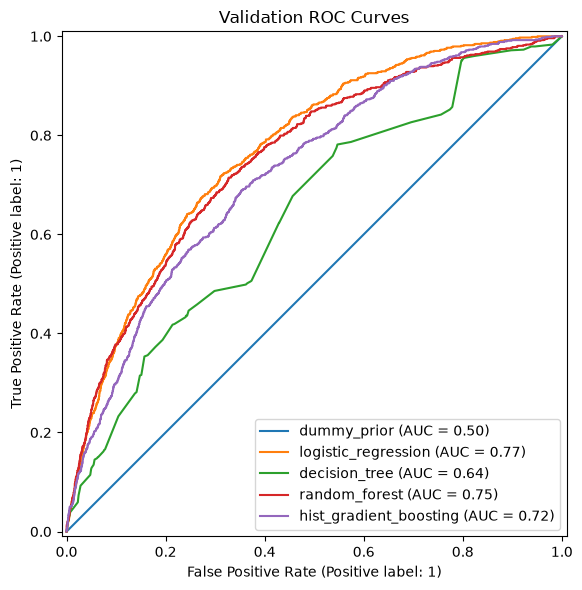

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, probability in validation_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_validation,
        probability,
        name=name,
        ax=ax,
    )

ax.set_title(
    "Validation ROC Curves"
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "13_validation_roc_curves.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 11. Select the winning model

The winner is selected using validation PR-AUC only.

**Do not use test metrics to choose the model.**

In [11]:
best_model_name = str(
    validation_metrics.iloc[0]["model"]
)

best_model = fitted_models[
    best_model_name
]

best_validation_probability = (
    validation_probabilities[
        best_model_name
    ]
)

print("Best validation model:", best_model_name)
print(
    "Validation PR-AUC:",
    f"{validation_metrics.iloc[0]['pr_auc']:.4f}",
)

Best validation model: random_forest
Validation PR-AUC: 0.1619


## 12. Threshold analysis on validation

PR-AUC is threshold-independent.

For classification decisions, threshold selection is a separate business decision.

As an initial reproducible baseline, choose the threshold that maximizes F1 on the validation set.

This threshold is then frozen before test evaluation.

In [12]:
threshold_result = find_best_f1_threshold(
    y_validation,
    best_validation_probability,
)

print(
    "Best validation F1 threshold:",
    f"{threshold_result.threshold:.4f}",
)
print(
    "Validation precision:",
    f"{threshold_result.precision:.4f}",
)
print(
    "Validation recall:",
    f"{threshold_result.recall:.4f}",
)
print(
    "Validation F1:",
    f"{threshold_result.f1:.4f}",
)

display(
    threshold_table(
        y_validation,
        best_validation_probability,
    )
)

Best validation F1 threshold: 0.2878
Validation precision: 0.1945
Validation recall: 0.3458
Validation F1: 0.2490


,pr_auc,roc_auc,precision,recall,f1,accuracy,positive_rate,threshold
0,0.1619,0.7515,0.0594,0.9730,0.1120,0.1704,0.8805,0.1000
1,0.1619,0.7515,0.1144,0.6748,0.1957,0.7017,0.3171,0.2000
2,0.1619,0.7515,0.1985,0.3021,0.2396,0.8969,0.0818,0.3000
3,0.1619,0.7515,0.2452,0.0977,0.1397,0.9353,0.0214,0.4000
4,0.1619,0.7515,0.2500,0.0244,0.0445,0.9436,0.0053,0.5000
5,0.1619,0.7515,0.6667,0.0103,0.0203,0.9465,0.0008,0.6000
6,0.1619,0.7515,0.0000,0.0000,0.0000,0.9462,0.0000,0.7000


## 13. Final test evaluation

Only now is the test set used.

Evaluate the selected model twice:

1. default threshold = 0.50;
2. validation-selected F1 threshold.

PR-AUC and ROC-AUC are identical between the two rows because they do not depend on the classification threshold.

In [13]:
test_probability = predict_positive_probability(
    best_model,
    X_test,
)

test_default_metrics = classification_metrics(
    y_test,
    test_probability,
    threshold=0.50,
)

test_tuned_metrics = classification_metrics(
    y_test,
    test_probability,
    threshold=threshold_result.threshold,
)

test_metrics = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "evaluation": "default_threshold",
            **test_default_metrics,
        },
        {
            "model": best_model_name,
            "evaluation": "validation_tuned_threshold",
            **test_tuned_metrics,
        },
    ]
)

display(test_metrics)

,model,evaluation,pr_auc,roc_auc,precision,recall,f1,accuracy,positive_rate,threshold
0,random_forest,default_threshold,0.0909,0.6299,0.1000,0.0011,0.0021,0.9336,0.0007,0.5000
1,random_forest,validation_tuned_threshold,0.0909,0.6299,0.0845,0.1481,0.1076,0.8384,0.1153,0.2878


## 14. Confusion matrices

In [14]:
confusion_default = confusion_matrix_frame(
    y_test,
    test_probability,
    threshold=0.50,
)

confusion_tuned = confusion_matrix_frame(
    y_test,
    test_probability,
    threshold=threshold_result.threshold,
)

print("Default threshold = 0.50")
display(confusion_default)

print(
    "Validation-selected threshold =",
    f"{threshold_result.threshold:.4f}",
)
display(confusion_tuned)

Default threshold = 0.50


,pred_on_time,pred_late
actual_on_time,13507,9
actual_late,951,1


Validation-selected threshold = 0.2878


,pred_on_time,pred_late
actual_on_time,11989,1527
actual_late,811,141


## 15. Plot best-model confusion matrix

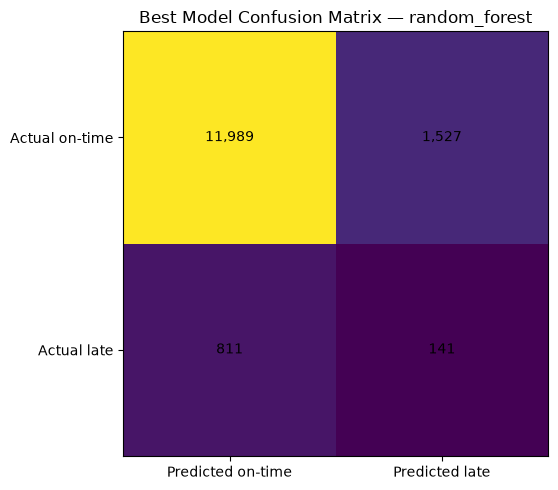

In [15]:
matrix = confusion_tuned.to_numpy()

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(matrix)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{matrix[i, j]:,}",
            ha="center",
            va="center",
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Predicted on-time", "Predicted late"]
)
ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["Actual on-time", "Actual late"]
)

ax.set_title(
    f"Best Model Confusion Matrix — {best_model_name}"
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "14_best_model_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 16. Save model and experiment metrics

In [16]:
validation_metrics.to_csv(
    METRICS_DIR / "model_validation_metrics.csv",
    index=False,
)

test_metrics.to_csv(
    METRICS_DIR / "best_model_test_metrics.csv",
    index=False,
)

confusion_default.to_csv(
    METRICS_DIR / "best_model_confusion_default.csv",
)

confusion_tuned.to_csv(
    METRICS_DIR / "best_model_confusion_tuned.csv",
)

joblib.dump(
    best_model,
    MODELS_DIR / "best_model.joblib",
)

metadata = {
    "best_model": best_model_name,
    "selection_metric": "pr_auc",
    "validation_pr_auc": float(
        validation_metrics.iloc[0]["pr_auc"]
    ),
    "threshold_selection": "best_validation_f1",
    "selected_threshold": float(
        threshold_result.threshold
    ),
    "test_pr_auc": float(
        test_default_metrics["pr_auc"]
    ),
    "test_roc_auc": float(
        test_default_metrics["roc_auc"]
    ),
    "feature_count": len(
        MODEL_FEATURE_COLUMNS
    ),
}

with (
    MODELS_DIR / "best_model_metadata.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

print("✓ Model artifacts and metrics saved.")

✓ Model artifacts and metrics saved.


## 17. Final validation

In [17]:
reloaded_model = joblib.load(
    MODELS_DIR / "best_model.joblib"
)

reloaded_probability = predict_positive_probability(
    reloaded_model,
    X_test.head(20),
)

assert len(reloaded_probability) == 20
assert np.isfinite(reloaded_probability).all()
assert (
    (reloaded_probability >= 0)
    & (reloaded_probability <= 1)
).all()

print("✓ Reloaded model inference validation passed.")

✓ Reloaded model inference validation passed.


# 18. Conclusions

After Run All, fill the conclusions using the actual validation ranking and test metrics above.

## Experiment design

All candidate models were trained on the chronological training split only.

Model selection used validation PR-AUC.

The test split was not used for model selection.

## Baseline importance

`DummyClassifier` establishes the no-skill reference point. Any useful model should materially exceed its PR-AUC.

## Model comparison

Compare:

- Logistic Regression for an interpretable linear baseline;
- Decision Tree for a simple nonlinear baseline;
- Random Forest for bagged tree interactions;
- HistGradientBoosting for boosted nonlinear interactions.

## Thresholding

Model ranking and threshold selection are separate decisions.

PR-AUC is used for model selection.

The initial operating threshold is selected on validation data by maximizing F1 and then frozen before test evaluation.

Later, the threshold should be adjusted according to the business cost of false negatives versus false positives.

## Temporal shift

Train, validation and test late-delivery rates differ materially.

Differences between validation and test performance should therefore be interpreted together with temporal distribution shift, not only model overfitting.

## Outputs

Phase 4 produces:

- `models/best_model.joblib`
- `models/best_model_metadata.json`
- `reports/metrics/model_validation_metrics.csv`
- `reports/metrics/best_model_test_metrics.csv`
- `reports/metrics/best_model_confusion_default.csv`
- `reports/metrics/best_model_confusion_tuned.csv`
- `reports/figures/12_validation_pr_curves.png`
- `reports/figures/13_validation_roc_curves.png`
- `reports/figures/14_best_model_confusion_matrix.png`

## Next step

Proceed to **Phase 5 — Evaluation & Model Analysis**.

Phase 5 should include:

- detailed threshold/business trade-off analysis;
- feature importance;
- permutation importance;
- model error analysis;
- segment analysis by state, distance and time;
- temporal robustness;
- calibration;
- final model-card style evaluation.